# Lag-Only Models — Predicting Daily Change in Polymarket Trump Probability

Four regression models trained exclusively on the lag features that survived feature selection in `preprocessing.ipynb`:
1. **Linear Regression** — linear baseline (OLS)
2. **Random Forest** — tree ensemble; tuned `max_depth`, `min_samples_leaf`
3. **SVM (RBF kernel)** — non-linear kernel regression; tuned `C`, `epsilon`
4. **XGBoost** — gradient boosting; tuned `max_depth`, `learning_rate`, `n_estimators`

**Target:** `Δ polymarket_trump_prob = prob(t) − prob(t−1)` — daily change in Trump win probability  
**Features (survived feature selection):**
- `polymarket_trump_prob_lag1` — Trump win probability yesterday  (|ρ| = 0.957)
- `polymarket_trump_prob_lag4` — Trump win probability 4 days ago  (|ρ| = 0.844)

Lags 2, 3, and 5 were removed by the pairwise-correlation deduplication step (|ρ| > 0.90 with lag1) in `preprocessing.ipynb`. We use exactly the output of that pipeline — no feature reconstruction.

**Hyperparameter tuning:** grid search using the same 3 walk-forward CV folds for RF, SVM, and XGBoost. Linear Regression has no hyperparameters to tune. The test set is completely untouched during tuning.

**Splits:** walk-forward expanding-window CV, 3 folds, gap = 1 day, held-out test = last 14 days  
**Metrics:** MAE, RMSE, Directional Accuracy, R²

## 1. Setup

In [ ]:
import sys, os, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, "../../..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product as iterproduct

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
try:
    from xgboost import XGBRegressor
except ImportError:
    raise ImportError("XGBoost not found. Install with: pip install xgboost")

from Functions.data_splits import (
    get_cv_folds, get_test_split, print_fold_summary, validate_no_leakage,
)
from house_style import (
    apply_style, BG_DARK, BG_PANEL, TEXT_PRIMARY, TEXT_MUTED,
    SPINE_COLOR, GRID_COLOR, DEMOCRAT, REPUBLICAN, NEUTRAL, PALETTE,
)
apply_style()

RANDOM_STATE = 42
TEST_DAYS    = 14
N_SPLITS     = 3
GAP          = 1

DATA_PATH = "../../../Data/3_Gold/basetable_preprocessed.csv"

MODEL_COLORS = {
    "Linear Regression": PALETTE[0],
    "Random Forest"    : PALETTE[1],
    "SVM (RBF)"        : PALETTE[4],
    "XGBoost"          : PALETTE[2],
}

print("Imports OK")

## 2. Load Data & Compute Target

We load `basetable_preprocessed.csv` — the cleaned, leakage-free output of `preprocessing.ipynb` — and use only the two polymarket lag columns that survived feature selection.

**Why only lag1 and lag4?**  
Feature selection in preprocessing dropped lag2, lag3, and lag5 because their pairwise Spearman correlation with lag1 exceeded 0.90 — they are near-redundant. We respect that decision and use the pipeline's output as-is.

**Target derivation:**  
`price_change` was removed as a *feature* in preprocessing because it leaks today's target. As the *target* itself it is perfectly valid:
```
target(t) = polymarket_trump_prob(t) − polymarket_trump_prob_lag1(t)
           = prob(t) − prob(t−1)
```

In [47]:
df_raw = pd.read_csv(DATA_PATH, parse_dates=["date"])
df_raw = df_raw.sort_values("date").reset_index(drop=True)

# Only the two lag columns that survived preprocessing feature selection
LAG_COLS = [
    "polymarket_trump_prob_lag1",
    "polymarket_trump_prob_lag4",
]

missing = [c for c in LAG_COLS if c not in df_raw.columns]
assert not missing, f"Missing columns: {missing} — re-run preprocessing.ipynb"

df = df_raw[["date"] + LAG_COLS].copy()
df["target"] = df_raw["polymarket_trump_prob"] - df_raw["polymarket_trump_prob_lag1"]

assert df.isna().sum().sum() == 0, "NaN detected — check basetable_preprocessed.csv"

print(f"Rows          : {len(df)}")
print(f"Date range    : {df['date'].min().date()} -> {df['date'].max().date()}")
print(f"Features ({len(LAG_COLS)}): {LAG_COLS}")
print(f"\nTarget (daily delta prob) stats:")
print(df["target"].describe().round(5))

Rows          : 123
Date range    : 2024-07-05 -> 2024-11-04
Features (2): ['polymarket_trump_prob_lag1', 'polymarket_trump_prob_lag4']

Target (daily delta prob) stats:
count    123.00000
mean      -0.00020
std        0.01782
min       -0.06000
25%       -0.01000
50%        0.00000
75%        0.00900
max        0.08000
Name: target, dtype: float64


## 3. Train/Val/Test Split

`get_test_split` carves off the **last 14 rows** (Oct 22 – Nov 4) as a completely held-out test set. These dates are never seen during training or model selection — they are used only once for the final reported numbers.

The remaining 109 rows form the **TV (train/validation) set**, split further into CV folds.

In [48]:
tv_idx, test_idx = get_test_split(df, test_days=TEST_DAYS)

df_tv   = df.iloc[tv_idx].reset_index(drop=True)
df_test = df.iloc[test_idx].reset_index(drop=True)

X_tv   = df_tv[LAG_COLS].values
y_tv   = df_tv["target"].values
X_test = df_test[LAG_COLS].values
y_test = df_test["target"].values

print(f"Train/val : {len(df_tv):>4} rows  ({df_tv['date'].min().date()} -> {df_tv['date'].max().date()})")
print(f"Test      : {len(df_test):>4} rows  ({df_test['date'].min().date()} -> {df_test['date'].max().date()})")

Train/val :  109 rows  (2024-07-05 -> 2024-10-21)
Test      :   14 rows  (2024-10-22 -> 2024-11-04)


## 4. CV Folds

We build **3 expanding-window folds** on the TV set with a 1-day gap between each train and validation window. The gap prevents rolling-feature bleed: if the last training day and the first validation day were adjacent, a rolling-average feature on day t could still include training rows.

Folds are built on `df_tv` with `test_days=None` — the test set has already been separated above, so we pass only the TV portion here.

`validate_no_leakage` asserts three things per fold:
1. No row index appears in both train and val
2. All training dates are strictly earlier than all validation dates
3. The calendar gap between the last training date and the first validation date is at least `GAP` days

In [49]:
folds = get_cv_folds(df_tv, n_splits=N_SPLITS, gap=GAP, test_days=None)
print_fold_summary(df_tv, folds)

print("\nLeakage validation:")
for i, (tr, va) in enumerate(folds, 1):
    validate_no_leakage(tr, va, df_tv, gap=GAP)
    print(f"  Fold {i}: OK")

Fold   Train start     Train end   #Train     Val start       Val end    #Val
-----------------------------------------------------------------------------
   1    2024-07-05    2024-07-31       27    2024-08-02    2024-08-28      27
   2    2024-07-05    2024-08-27       54    2024-08-29    2024-09-24      27
   3    2024-07-05    2024-09-23       81    2024-09-25    2024-10-21      27

Leakage validation:
  Fold 1: OK
  Fold 2: OK
  Fold 3: OK


## 5. Helper Functions

**`directional_accuracy`** — fraction of predictions where the predicted sign matches the actual sign. A value of 0.5 means the model is no better than a coin flip for calling the direction of the next move.

**`compute_metrics`** — returns MAE, RMSE, Directional Accuracy, R² as a dict.

**`tune_hyperparams`** — grid search using the walk-forward CV folds:
- Iterates over all hyperparameter combinations in `param_grid`
- For each combination: runs every CV fold, fits a scaler on the train fold only (if `scale=True`), records fold MAEs
- Returns the best parameter dict (minimum mean CV MAE) and a sorted results DataFrame
- **Note:** since tuning and evaluation use the same folds, CV metrics after tuning are slightly optimistic. With only ~27–81 training rows, nested CV would produce unstable inner estimates, so this trade-off is accepted.

**`cv_evaluate`** — walk-forward CV loop with a given model factory; reports per-fold and mean metrics.

**`final_eval`** — retrains on all TV data with given factory, evaluates once on the held-out test set.

In [ ]:
from Functions.evaluation_metrics import (
    directional_accuracy, compute_metrics, cv_evaluate, final_eval
)

Helper functions defined.


## 6. Model 1 — Linear Regression

Linear Regression (OLS) fits a hyperplane through the feature space by minimising the sum of squared residuals. With only two features (lag1 and lag4) it is essentially a weighted combination of yesterday's price and the price four days ago, plus an intercept.

**Why include it?** It is the simplest possible non-trivial regressor and serves as the theoretical floor: if no other model can beat it, the features carry no non-linear signal. It also gives fully interpretable coefficients — the sign and magnitude directly show the contribution of each lag.

**No hyperparameters to tune** — OLS has a closed-form solution.

**Scaling applied** — not strictly necessary for OLS (the solution is scale-invariant), but applied for consistency so coefficients are comparable across the two features.

In [ ]:
lr_factory = LinearRegression

print("=== Linear Regression — CV ===")
lr_cv = cv_evaluate(lr_factory, folds, X_tv, y_tv, scale=True)
lr_cv.round(4)

In [ ]:
lr_model, lr_pred, lr_test = final_eval(
    lr_factory, X_tv, y_tv, X_test, y_test, scale=True
)
print("Linear Regression — Test set:")
for k, v in lr_test.items():
    print(f"  {k}: {v:.4f}")

sc_lr = StandardScaler().fit(X_tv)
lr_coef_model = LinearRegression().fit(sc_lr.transform(X_tv), y_tv)
coefs = pd.Series(lr_coef_model.coef_, index=LAG_COLS)
print(f"\nFitted coefficients (standardised features):")
print(coefs.round(5).to_string())

## 8. Model 3 — Random Forest Regressor

Random Forest builds an ensemble of decision trees, each trained on a bootstrap sample with a random feature subset at each split. Predictions are averaged across trees, reducing variance compared to a single tree.

**Why RF with only 5 features?** Even a small feature set can exhibit interactions (e.g., a large lag1 combined with a specific lag4 pattern) that linear models miss. RF captures these non-linearities without explicit feature engineering.

**Fixed hyperparameters:** `n_estimators=200` (sufficient ensemble size), `random_state=42`.

**Tuned hyperparameters:**
- `max_depth` — maximum tree depth; shallow trees prevent overfitting on small training folds
- `min_samples_leaf` — minimum observations per leaf; higher values smooth predictions

**No scaling required** — decision-tree splits are threshold-based, scale-invariant.

In [56]:
def make_rf(max_depth, min_samples_leaf):
    return RandomForestRegressor(
        n_estimators=200,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

# ── Tuning ────────────────────────────────────────────────────────────────────
rf_param_grid = {
    "max_depth"       : [2, 3, 4, 5],
    "min_samples_leaf": [1, 2, 3, 5],
}

print("=== Random Forest — Hyperparameter Tuning ===")
rf_best, rf_tune_df = tune_hyperparams(
    make_rf, rf_param_grid, folds, X_tv, y_tv, scale=False
)
print(f"  Best params : {rf_best}")
print(f"\n  Top-5 configurations (sorted by CV MAE):")
print(rf_tune_df.head(5).to_string(index=False))

# ── CV evaluation with best params ────────────────────────────────────────────
rf_factory = lambda: make_rf(**rf_best)
print("\n=== Random Forest — CV (best params) ===")
rf_cv = cv_evaluate(rf_factory, folds, X_tv, y_tv, scale=False)
rf_cv.round(4)

=== Random Forest — Hyperparameter Tuning ===
  Best params : {'max_depth': np.int64(2), 'min_samples_leaf': np.int64(5)}

  Top-5 configurations (sorted by CV MAE):
 max_depth  min_samples_leaf   cv_mae  cv_mae_std
         2                 5 0.010658    0.002192
         2                 3 0.011124    0.002632
         3                 5 0.011168    0.002653
         4                 5 0.011326    0.002734
         5                 5 0.011328    0.002754

=== Random Forest — CV (best params) ===
  Fold 1: MAE=0.0124  RMSE=0.0157  DA=0.444  R2=-0.0858
  Fold 2: MAE=0.0076  RMSE=0.0098  DA=0.407  R2=0.0035
  Fold 3: MAE=0.0121  RMSE=0.0165  DA=0.444  R2=-0.3387
  -- Mean --  MAE=0.0107  RMSE=0.0140  DA=0.432  R2=-0.1403


,MAE,RMSE,Dir. Accuracy,R2
1,0.0124,0.0157,0.4444,-0.0858
2,0.0076,0.0098,0.4074,0.0035
3,0.0121,0.0165,0.4444,-0.3387
Mean,0.0107,0.0140,0.4321,-0.1403
Std,0.0027,0.0036,0.0214,0.1775


Random Forest — Test set:
  MAE: 0.0170
  RMSE: 0.0201
  Dir. Accuracy: 0.5714
  R2: 0.0073


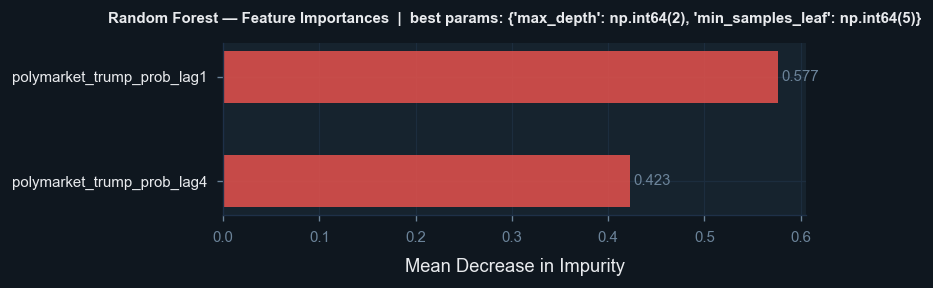

In [57]:
rf_model, rf_pred, rf_test = final_eval(
    rf_factory, X_tv, y_tv, X_test, y_test, scale=False
)
print("Random Forest — Test set:")
for k, v in rf_test.items():
    print(f"  {k}: {v:.4f}")

fi = pd.Series(rf_model.feature_importances_, index=LAG_COLS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 2.5))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(BG_PANEL)
bars = ax.barh(fi.index, fi.values, color=MODEL_COLORS["Random Forest"], alpha=0.85, height=0.5)
for bar, v in zip(bars, fi.values):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
            f"{v:.3f}", va="center", ha="left", fontsize=9, color=TEXT_MUTED)
ax.set_xlabel("Mean Decrease in Impurity", color=TEXT_PRIMARY)
ax.set_title(f"Random Forest — Feature Importances  |  best params: {rf_best}",
             color=TEXT_PRIMARY, fontweight="bold", fontsize=9)
for spine in ax.spines.values(): spine.set_edgecolor(SPINE_COLOR)
ax.tick_params(colors=TEXT_MUTED)
ax.set_yticklabels(fi.index, color=TEXT_PRIMARY)
ax.grid(axis="x", color=GRID_COLOR, linewidth=0.7)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

## 9. Model 4 — Support Vector Regression (RBF kernel)

SVR finds a regression function that keeps predictions within an epsilon-tube around the true values while maximising the margin. The **Radial Basis Function (RBF) kernel** maps features into an infinite-dimensional space, enabling non-linear regression.

**Fixed hyperparameter:** `gamma='scale'` — sets gamma = 1 / (n_features × Var(X)); data-adaptive default.

**Tuned hyperparameters:**
- `C` — regularisation strength (inverse of λ); higher C = tighter fit, more support vectors, less regularisation
- `epsilon` — tube half-width; predictions within ε of truth incur zero loss. Daily changes are small (std ≈ 0.018), so small ε values are appropriate

**Scaling required** — SVR maximises a geometric margin; unscaled features distort distances in feature space.

In [58]:
def make_svr(C, epsilon):
    return SVR(kernel="rbf", C=C, epsilon=epsilon, gamma="scale")

# ── Tuning ────────────────────────────────────────────────────────────────────
svr_param_grid = {
    "C"      : [0.1, 1.0, 10.0, 100.0],
    "epsilon": [0.0001, 0.001, 0.01, 0.05],
}

print("=== SVM (RBF) — Hyperparameter Tuning ===")
svr_best, svr_tune_df = tune_hyperparams(
    make_svr, svr_param_grid, folds, X_tv, y_tv, scale=True
)
print(f"  Best params : {svr_best}")
print(f"\n  Top-5 configurations (sorted by CV MAE):")
print(svr_tune_df.head(5).to_string(index=False))

# ── CV evaluation with best params ────────────────────────────────────────────
svr_factory = lambda: make_svr(**svr_best)
print("\n=== SVM (RBF) — CV (best params) ===")
svm_cv = cv_evaluate(svr_factory, folds, X_tv, y_tv, scale=True)
svm_cv.round(4)

=== SVM (RBF) — Hyperparameter Tuning ===
  Best params : {'C': np.float64(0.1), 'epsilon': np.float64(0.05)}

  Top-5 configurations (sorted by CV MAE):
    C  epsilon   cv_mae  cv_mae_std
  0.1    0.050 0.011579    0.002212
  1.0    0.050 0.011711    0.002079
100.0    0.050 0.011711    0.002079
 10.0    0.050 0.011711    0.002079
  0.1    0.001 0.012622    0.004233

=== SVM (RBF) — CV (best params) ===
  Fold 1: MAE=0.0145  RMSE=0.0179  DA=0.444  R2=-0.4073
  Fold 2: MAE=0.0092  RMSE=0.0121  DA=0.481  R2=-0.5112
  Fold 3: MAE=0.0111  RMSE=0.0138  DA=0.667  R2=0.0697
  -- Mean --  MAE=0.0116  RMSE=0.0146  DA=0.531  R2=-0.2830


,MAE,RMSE,Dir. Accuracy,R2
1,0.0145,0.0179,0.4444,-0.4073
2,0.0092,0.0121,0.4815,-0.5112
3,0.0111,0.0138,0.6667,0.0697
Mean,0.0116,0.0146,0.5309,-0.2830
Std,0.0027,0.0030,0.1191,0.3098


In [59]:
svm_model, svm_pred, svm_test = final_eval(
    svr_factory, X_tv, y_tv, X_test, y_test, scale=True
)
print("SVM (RBF) — Test set:")
for k, v in svm_test.items():
    print(f"  {k}: {v:.4f}")

SVM (RBF) — Test set:
  MAE: 0.0202
  RMSE: 0.0269
  Dir. Accuracy: 0.5000
  R2: -0.7696


## 10. Model 5 — XGBoost Regressor

XGBoost builds an additive ensemble of shallow regression trees sequentially: each new tree fits the pseudo-residuals (negative gradient of the loss) of the current ensemble. This boosting approach typically outperforms bagging (Random Forest) when individual trees are kept very shallow and many are combined.

**Fixed hyperparameters:** `subsample=0.8`, `colsample_bytree=0.8` (stochastic boosting for regularisation), `objective='reg:squarederror'`, `random_state=42`.

**Tuned hyperparameters:**
- `max_depth` — depth of each tree; boosting benefits from very shallow trees (depth 2–4)
- `learning_rate` — shrinkage applied to each tree's contribution; lower = more robust but needs more trees
- `n_estimators` — number of boosting rounds; jointly tuned with learning_rate

**No scaling required** — tree-based splits are threshold-based, scale-invariant.

In [60]:
def make_xgb(max_depth, learning_rate, n_estimators):
    return XGBRegressor(
        max_depth=int(max_depth),
        learning_rate=learning_rate,
        n_estimators=int(n_estimators),
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        verbosity=0,
    )

# ── Tuning ────────────────────────────────────────────────────────────────────
xgb_param_grid = {
    "max_depth"    : [2, 3, 4],
    "learning_rate": [0.01, 0.05, 0.1],
    "n_estimators" : [100, 200],
}

print("=== XGBoost — Hyperparameter Tuning ===")
xgb_best, xgb_tune_df = tune_hyperparams(
    make_xgb, xgb_param_grid, folds, X_tv, y_tv, scale=False
)
print(f"  Best params : {xgb_best}")
print(f"\n  Top-5 configurations (sorted by CV MAE):")
print(xgb_tune_df.head(5).to_string(index=False))

# ── CV evaluation with best params ────────────────────────────────────────────
xgb_factory = lambda: make_xgb(**xgb_best)
print("\n=== XGBoost — CV (best params) ===")
xgb_cv = cv_evaluate(xgb_factory, folds, X_tv, y_tv, scale=False)
xgb_cv.round(4)

=== XGBoost — Hyperparameter Tuning ===
  Best params : {'max_depth': np.int64(2), 'learning_rate': np.float64(0.01), 'n_estimators': np.int64(100)}

  Top-5 configurations (sorted by CV MAE):
 max_depth  learning_rate  n_estimators   cv_mae  cv_mae_std
         2           0.01           100 0.011077    0.002659
         3           0.01           100 0.011126    0.002910
         4           0.01           100 0.011248    0.002972
         2           0.01           200 0.011862    0.003620
         3           0.01           200 0.012164    0.004022

=== XGBoost — CV (best params) ===
  Fold 1: MAE=0.0141  RMSE=0.0171  DA=0.556  R2=-0.2968
  Fold 2: MAE=0.0076  RMSE=0.0099  DA=0.519  R2=-0.0034
  Fold 3: MAE=0.0115  RMSE=0.0159  DA=0.444  R2=-0.2388
  -- Mean --  MAE=0.0111  RMSE=0.0143  DA=0.506  R2=-0.1797


,MAE,RMSE,Dir. Accuracy,R2
1,0.0141,0.0171,0.5556,-0.2968
2,0.0076,0.0099,0.5185,-0.0034
3,0.0115,0.0159,0.4444,-0.2388
Mean,0.0111,0.0143,0.5062,-0.1797
Std,0.0033,0.0039,0.0566,0.1554


XGBoost — Test set:
  MAE: 0.0162
  RMSE: 0.0200
  Dir. Accuracy: 0.5714
  R2: 0.0165


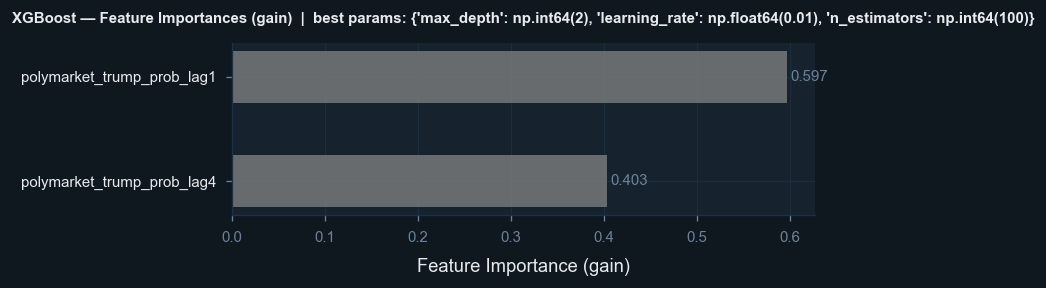

In [61]:
xgb_model, xgb_pred, xgb_test = final_eval(
    xgb_factory, X_tv, y_tv, X_test, y_test, scale=False
)
print("XGBoost — Test set:")
for k, v in xgb_test.items():
    print(f"  {k}: {v:.4f}")

# Gain-based feature importance: average improvement in squared-error loss
# brought by splitting on each feature across all boosting rounds
fi_xgb = pd.Series(xgb_model.feature_importances_, index=LAG_COLS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 2.5))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(BG_PANEL)
bars = ax.barh(fi_xgb.index, fi_xgb.values, color=MODEL_COLORS["XGBoost"], alpha=0.85, height=0.5)
for bar, v in zip(bars, fi_xgb.values):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
            f"{v:.3f}", va="center", ha="left", fontsize=9, color=TEXT_MUTED)
ax.set_xlabel("Feature Importance (gain)", color=TEXT_PRIMARY)
ax.set_title(f"XGBoost — Feature Importances (gain)  |  best params: {xgb_best}",
             color=TEXT_PRIMARY, fontweight="bold", fontsize=9)
for spine in ax.spines.values(): spine.set_edgecolor(SPINE_COLOR)
ax.tick_params(colors=TEXT_MUTED)
ax.set_yticklabels(fi_xgb.index, color=TEXT_PRIMARY)
ax.grid(axis="x", color=GRID_COLOR, linewidth=0.7)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

## 11. Model Comparison

We compare all four models across two dimensions:

**CV performance** (mean over 3 walk-forward folds) — reflects generalisation across different campaign phases. This is the primary criterion for model selection. Note that CV metrics for the tuned models are slightly optimistic because the same folds were used for both hyperparameter selection and evaluation.

**Test set performance** (Oct 22 – Nov 4) — single held-out evaluation on the final two pre-election weeks. Used for reporting only; never influences model selection or tuning.

**Metrics:**
- **MAE** — Mean Absolute Error in probability-point units (0.01 = 1 pp)
- **RMSE** — penalises large errors more than MAE
- **Dir. Accuracy** — fraction of correct sign predictions; 0.5 = coin flip
- **R²** — fraction of variance explained; 0 = mean predictor, negative = worse than mean

In [ ]:
cv_summary = pd.DataFrame({
    "Linear Regression": lr_cv.loc["Mean"],
    "Random Forest"    : rf_cv.loc["Mean"],
    "SVM (RBF)"        : svm_cv.loc["Mean"],
    "XGBoost"          : xgb_cv.loc["Mean"],
}).T.round(4)

best_params_col = {
    "Linear Regression": "— (no tuning)",
    "Random Forest"    : f"d={rf_best['max_depth']}, leaf={rf_best['min_samples_leaf']}",
    "SVM (RBF)"        : f"C={svr_best['C']}, ε={svr_best['epsilon']}",
    "XGBoost"          : f"d={xgb_best['max_depth']}, lr={xgb_best['learning_rate']}, n={int(xgb_best['n_estimators'])}",
}
cv_summary.insert(0, "Best params", pd.Series(best_params_col))

print("CV performance (mean across 3 walk-forward folds):")
display(cv_summary)

In [ ]:
test_summary = pd.DataFrame({
    "Linear Regression": lr_test,
    "Random Forest"    : rf_test,
    "SVM (RBF)"        : svm_test,
    "XGBoost"          : xgb_test,
}).T.round(4)

print("Test set performance (Oct 22 -- Nov 4, 2024):")
display(test_summary)

In [ ]:
test_dates = df_test["date"].values
preds_list = [
    ("Linear Regression", lr_pred),
    ("Random Forest",     rf_pred),
    ("SVM (RBF)",         svm_pred),
    ("XGBoost",           xgb_pred),
]

fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)
fig.patch.set_facecolor(BG_DARK)

for ax, (label, pred) in zip(axes, preds_list):
    ax.set_facecolor(BG_PANEL)
    ax.plot(test_dates, y_test, label="Actual",    color=TEXT_PRIMARY, linewidth=2)
    ax.plot(test_dates, pred,   label="Predicted", color=MODEL_COLORS[label],
            linewidth=1.8, linestyle="--")
    ax.axhline(0, color=TEXT_MUTED, linewidth=0.9, linestyle=":")
    da  = directional_accuracy(y_test, pred)
    mae = mean_absolute_error(y_test, pred)
    ax.set_title(f"{label}  |  DA={da:.2f}  MAE={mae:.4f}",
                 color=MODEL_COLORS[label], fontweight="bold", fontsize=10)
    ax.set_ylabel("Delta prob", color=TEXT_PRIMARY, fontsize=9)
    ax.legend(loc="upper right", facecolor=BG_PANEL, edgecolor=SPINE_COLOR,
              labelcolor=TEXT_PRIMARY, fontsize=8)
    for spine in ax.spines.values(): spine.set_edgecolor(SPINE_COLOR)
    ax.tick_params(colors=TEXT_MUTED)
    ax.grid(axis="y", color=GRID_COLOR, linewidth=0.7)
    ax.set_axisbelow(True)

axes[-1].set_xlabel("Date", color=TEXT_PRIMARY)
plt.xticks(rotation=25, ha="right")
fig.suptitle("Test-set predictions vs actuals\nDaily delta Polymarket Trump probability — lag features only",
             color=TEXT_PRIMARY, fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
metrics_plot = ["MAE", "RMSE", "Dir. Accuracy", "R2"]
model_names  = list(MODEL_COLORS.keys())
colors_list  = list(MODEL_COLORS.values())

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
fig.patch.set_facecolor(BG_DARK)

for ax, metric in zip(axes, metrics_plot):
    ax.set_facecolor(BG_PANEL)
    vals = [test_summary.loc[m, metric] for m in model_names]
    bars = ax.bar(range(len(model_names)), vals, color=colors_list, alpha=0.85, width=0.6)

    if metric == "Dir. Accuracy":
        ax.axhline(0.5, color=TEXT_MUTED, linestyle="--", linewidth=1.2, label="Chance (0.5)")
    if metric == "R2":
        ax.axhline(0, color=TEXT_MUTED, linestyle="--", linewidth=1.2, label="Mean predictor")

    for bar, val in zip(bars, vals):
        offset = abs(val) * 0.03 + 0.001
        va     = "bottom" if val >= 0 else "top"
        y_pos  = bar.get_height() + offset if val >= 0 else bar.get_height() - offset
        ax.text(bar.get_x() + bar.get_width()/2, y_pos,
                f"{val:.3f}", ha="center", va=va, fontsize=8, color=TEXT_MUTED)

    ax.set_title(metric, color=TEXT_PRIMARY, fontweight="bold")
    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels([m.replace(" ", "\n") for m in model_names],
                       fontsize=8, color=TEXT_MUTED)
    for spine in ax.spines.values(): spine.set_edgecolor(SPINE_COLOR)
    ax.tick_params(colors=TEXT_MUTED)
    ax.grid(axis="y", color=GRID_COLOR, linewidth=0.7)
    ax.set_axisbelow(True)
    if metric in ("Dir. Accuracy", "R2"):
        ax.legend(facecolor=BG_PANEL, edgecolor=SPINE_COLOR, labelcolor=TEXT_PRIMARY, fontsize=8)

fig.suptitle("Test-set metric comparison — Lag-only baseline",
             color=TEXT_PRIMARY, fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()